In [182]:
import copy
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lab_utils_common import batch_gradient_descent

from typing import Tuple



%matplotlib inline

In [183]:
df = pd.read_csv('./insurance.csv')

In [79]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [81]:
binary_encoding = {
    'sex': {'female': 0, 'male': 1},
    'smoker': {'no': 0, 'yes': 1}
}

# Using map method for binary encoding
for column, mapping in binary_encoding.items():
    df[column] = df[column].map(mapping)

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520


In [82]:
# Encode multi-class categories manually
regions = df['region'].unique()
region_encoding = {region: i for i, region in enumerate(regions)}

# Add one-hot encoding columns
for region in regions:
    df[f'region_{region}'] = (df['region'] == region).astype(int)

# Drop the original 'region' column
df.drop(columns=['region'], inplace=True)

# df['b'] = 1

In [83]:
# Standardize numerical features manually
numerical_features = ['age', 'bmi', 'children', 'charges']

for feature in numerical_features:
    mean = df[feature].mean()
    std = df[feature].std()
    df[feature] = (df[feature] - mean) / std

In [84]:
df.head()

,age,sex,bmi,children,smoker,charges,region_southwest,region_southeast,region_northwest,region_northeast
0,-1.438227,0,-0.453151,-0.908274,1,0.298472,1,0,0,0
1,-1.509401,1,0.509431,-0.078738,0,-0.953333,0,1,0,0
2,-0.797655,1,0.383164,1.580335,0,-0.728402,0,1,0,0
3,-0.441782,1,-1.305043,-0.908274,0,0.719574,0,0,1,0
4,-0.512957,1,-0.292447,-0.908274,0,-0.776512,0,0,1,0


In [85]:
# Shuffle the DataFrame
df = df.sample(frac=1, random_state=42).reset_index(drop=True)


In [86]:
# Define the split ratio
train_ratio = 0.8
split_index = int(len(df) * train_ratio)


In [87]:
# Split the data
df_train = df[:split_index]
df_dev = df[split_index:]


In [88]:
# Separate features and target for training set
X_train = df_train.drop('charges', axis=1)
y_train = df_train['charges']

# Separate features and target for development set
X_dev = df_dev.drop('charges', axis=1)
y_dev = df_dev['charges']


In [100]:
def predict(X: np.ndarray, w: np.ndarray) -> np.ndarray:
    """
    Predicts the target values for the given input features.

    Parameters:
        X (np.ndarray[float, ndim=2]): The input features of shape (m, n)
        where m is the number of samples and n is the number of features.
        w (np.ndarray[float, ndim=1]): The coefficients of shape (n,).

    Returns:
        np.ndarray[float, ndim=1]: The predicted target values of shape (m,).
    """
    predictions: np.ndarray = X.dot(w) 
    return predictions


In [187]:
alpha = 0.001
num_iters = 1000
weights = np.zeros(X_train.shape[1])
b = 0
final_weights,final_bais, cost_history = batch_gradient_descent(X_train, y_train, weights, b, alpha, num_iters)
cost_history['cost'][-1]

np.float64(0.35550407975838105)

In [186]:
dev_cost = compute_cost_matrix(X_dev, y_dev, final_weights, final_bais)
print(dev_cost)

0.38558233741973563


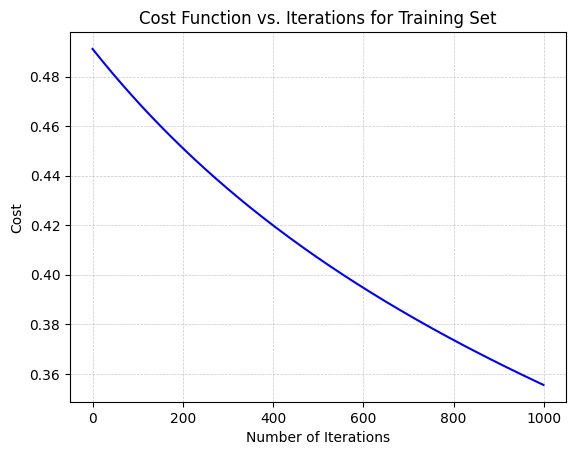

In [174]:


plt.plot(cost_history['iter'], cost_history['cost'], color='blue')

plt.xlabel('Number of Iterations')  
plt.ylabel('Cost')  
plt.title('Cost Function vs. Iterations for Training Set')  
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)  

plt.show()